# Model Training

### Setup MLFlow

In [ ]:
# # SETUP BLOCK (Run once per project lifetime)
# import mlflow
# import os

# # 1. Define Absolute Paths
# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# db_uri = f"sqlite:///{os.path.join(project_root, 'mlflow.db')}"
# artifact_uri = "file:///" + os.path.join(project_root, "mlruns").replace("\\", "/")

# # 2. Connect
# mlflow.set_tracking_uri(db_uri)

# # 3. Create (Safe Check)
# if not mlflow.get_experiment_by_name("WaterQuality"):
#     mlflow.create_experiment("WaterQuality", artifact_location=artifact_uri)

2026/03/09 15:40:43 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/09 15:40:43 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [8]:
import mlflow
import os

# Set tracking URI (relative to notebook location)
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

# Set experiment name
mlflow.set_experiment("WaterQuality")

<Experiment: artifact_location='file:///d:/projects/water-quality-prediction/notebooks/mlruns/1', creation_time=1773038149702, experiment_id='1', last_update_time=1773038149702, lifecycle_stage='active', name='WaterQuality', tags={'mlflow.experimentKind': 'custom_model_development'}>

### Import Libraries

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import shap
import time

from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.inspection import permutation_importance

# Regression Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings("ignore")

### Load Data

In [ ]:
DATA_PATH = '../data/processed/data_with_regions.parquet'
df = pd.read_parquet(DATA_PATH)

TARGET_COLS = ['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
META_COLS = ['Region'] # The region tag we made for LORO

# Dynamically grab every column that isn't a target or metadata
UNIVERSAL_FEATURES = [
    col for col in df.columns 
    if col not in TARGET_COLS + META_COLS
]

print(f"Total rows: {len(df)}")
print(f"{len(UNIVERSAL_FEATURES)} features detected for training.")

Total rows: 9319


### Define Model Hyperparameters & Preprocessor

In [13]:
data_params = {
    "validation_strategy": "Leave-One-Region-Out (LORO) Spatial CV",
    "folds": "3 (Northern_Bulk, Western_Cape, Eastern_Cape)",
    "pipeline_architecture": "ColumnTransformer (Fit strictly INSIDE CV loops)",
    "features_used": "swir22, NDMI, MNDWI, pet (Universal 4)", 
    "imputation_strategy": "Median via Train Folds Only",
    "target_handling": "Raw Values (Disabled log1p to match benchmark)" 
}

# The Preprocessor (Will be initialized and fitted dynamically per fold)
def get_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=False)),
        ('scaler', StandardScaler()),
    ])
    return ColumnTransformer(
        transformers=[('num', numeric_transformer, UNIVERSAL_FEATURES)],
        remainder='drop'
    )

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

### Model Training & Evaluation

In [14]:
results = []
regions = df['Region'].unique()

# Calculate total iterations for the outer progress bar
total_runs = len(TARGET_COLS) * len(models)

# 1. Outer Progress Bar (Tracks the 9 combinations)
with tqdm(total=total_runs, desc="Overall Progress") as pbar:
    for target in TARGET_COLS:
        for model_name, base_model in models.items():
            run_name = f"{model_name}_{target.replace(' ', '')}_LORO"
            
            with mlflow.start_run(run_name=run_name):
                # Use tqdm.write instead of print to prevent progress bar corruption
                tqdm.write(f"\n--- Cross-Validating {run_name} ---")
                
                # Arrays to store Out-Of-Fold (OOF) predictions for honest scoring
                oof_y_true = []
                oof_y_pred = []
                
                cv_start_time = time.time()
                
                # ==========================================
                # 1. The LORO Cross-Validation Loop
                # ==========================================
                # 2. Inner Progress Bar (Tracks the 3 spatial folds, disappears when done)
                for holdout_region in tqdm(regions, desc=f"Folds for {model_name}", leave=False):
                    tqdm.write(f"  Holding out {holdout_region}...")
                    
                    # Split Data geographically
                    train_df = df[df['Region'] != holdout_region]
                    test_df = df[df['Region'] == holdout_region]
                    
                    X_train_raw = train_df[UNIVERSAL_FEATURES]
                    y_train = train_df[target]
                    X_test_raw = test_df[UNIVERSAL_FEATURES]
                    y_test = test_df[target]
                    
                    # Dynamically fit preprocessor strictly on the training folds
                    fold_preprocessor = get_preprocessor()
                    X_train = fold_preprocessor.fit_transform(X_train_raw)
                    X_test = fold_preprocessor.transform(X_test_raw)
                    
                    # Train & Predict
                    model = base_model
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    
                    # Store predictions for the overall OOF score
                    oof_y_true.extend(y_test)
                    oof_y_pred.extend(y_pred)
                    
                cv_time = time.time() - cv_start_time
                
                # ==========================================
                # 2. Honest OOF Scoring & Logging
                # ==========================================
                oof_y_true = np.array(oof_y_true)
                oof_y_pred = np.array(oof_y_pred)
                
                metrics = {
                    "rmse": np.sqrt(mean_squared_error(oof_y_true, oof_y_pred)),
                    "mae": mean_absolute_error(oof_y_true, oof_y_pred),
                    "r2": r2_score(oof_y_true, oof_y_pred),
                    "cv_time_sec": cv_time
                }
                
                mlflow.log_params(data_params)
                mlflow.log_param("target", target)
                mlflow.log_param("model", model_name)
                mlflow.log_metrics(metrics)
                
                # Actual vs Predicted Plot (Using OOF Predictions)
                fig, ax = plt.subplots(figsize=(6, 6))
                ax.scatter(oof_y_true, oof_y_pred, alpha=0.4, color='teal')
                min_val = min(oof_y_true.min(), oof_y_pred.min())
                max_val = max(oof_y_true.max(), oof_y_pred.max())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
                ax.set_xlabel('Actual Values (All Folds)')
                ax.set_ylabel('Predicted Values (OOF)')
                ax.set_title(f'True Generalization - {run_name}')
                mlflow.log_figure(fig, 'actual_vs_predicted_oof.png')
                plt.close(fig)

                # ==========================================
                # 3. Retrain on 100% of Data for Submission
                # ==========================================
                tqdm.write("  Retraining final model on 100% of data...")
                final_preprocessor = get_preprocessor()
                X_all = final_preprocessor.fit_transform(df[UNIVERSAL_FEATURES])
                y_all = df[target]
                
                final_model = base_model
                final_model.fit(X_all, y_all)
                
                # Save the final Preprocessor artifact (overwrites with the 100% trained version)
                os.makedirs('../models', exist_ok=True)
                joblib.dump(final_preprocessor, f"../models/preprocessor.joblib")
                
                # Log Model
                mlflow.sklearn.log_model(final_model, name="model")
                
                results.append({
                    "target": target,
                    "model": model_name,
                    "rmse": metrics["rmse"],
                    "mae": metrics["mae"],
                    "r2": metrics["r2"]
                })
            
            # Update the outer progress bar after completing a full model run
            pbar.update(1)

print("\n=== All 9 LORO runs complete! Models trained on 100% data and logged to MLflow. ===")

Overall Progress:   0%|          | 0/9 [00:00<?, ?it/s]


--- Cross-Validating Ridge_TotalAlkalinity_LORO ---


Folds for Ridge:   0%|          | 0/3 [00:00<?, ?it/s]

  Holding out Northern_Bulk...
  Holding out Western_Cape...
  Holding out Eastern_Cape...
  Retraining final model on 100% of data...

--- Cross-Validating RandomForest_TotalAlkalinity_LORO ---


Folds for RandomForest:   0%|          | 0/3 [00:00<?, ?it/s]

...

  Holding out Northern_Bulk...
  Holding out Western_Cape...
  Holding out Eastern_Cape...
  Retraining final model on 100% of data...

--- Cross-Validating RandomForest_DissolvedReactivePhosphorus_LORO ---


Folds for RandomForest:   0%|          | 0/3 [00:00<?, ?it/s]

  Holding out Northern_Bulk...
  Holding out Western_Cape...
  Holding out Eastern_Cape...
  Retraining final model on 100% of data...

--- Cross-Validating XGBoost_DissolvedReactivePhosphorus_LORO ---


Folds for XGBoost:   0%|          | 0/3 [00:00<?, ?it/s]

  Holding out Northern_Bulk...
  Holding out Western_Cape...
  Holding out Eastern_Cape...
  Retraining final model on 100% of data...

=== All 9 LORO runs complete! Models trained on 100% data and logged to MLflow. ===


### Model Comparison

In [15]:
results_df = pd.DataFrame(results)

# Pivot for a clean comparison view
for metric in ["rmse", "mae", "r2"]:
    print(f"\n{'='*50}")
    print(f"  {metric.upper()} by Target × Model")
    print(f"{'='*50}")
    pivot = results_df.pivot(index="target", columns="model", values=metric)
    pivot = pivot[["Ridge", "RandomForest", "XGBoost"]]  # fix column order
    
    # Highlight min for rmse/mae, max for r2
    if metric in ["rmse", "mae"]:
        display(pivot.style.highlight_min(axis=1, color="green").format("{:.4f}"))
    else:
        display(pivot.style.highlight_max(axis=1, color="green").format("{:.4f}"))


  RMSE by Target × Model


model,Ridge,RandomForest,XGBoost
target,,,
Dissolved Reactive Phosphorus,55.5718,56.6817,57.1441
Electrical Conductance,361.2808,390.0991,378.8275
Total Alkalinity,85.4281,92.4204,91.3791



  MAE by Target × Model


model,Ridge,RandomForest,XGBoost
target,,,
Dissolved Reactive Phosphorus,35.6980,35.7774,36.1742
Electrical Conductance,283.1020,299.0105,291.7477
Total Alkalinity,68.0941,71.9822,71.6032



  R2 by Target × Model


model,Ridge,RandomForest,XGBoost
target,,,
Dissolved Reactive Phosphorus,-0.1884,-0.2363,-0.2566
Electrical Conductance,-0.1165,-0.3017,-0.2275
Total Alkalinity,-0.3083,-0.5312,-0.4969


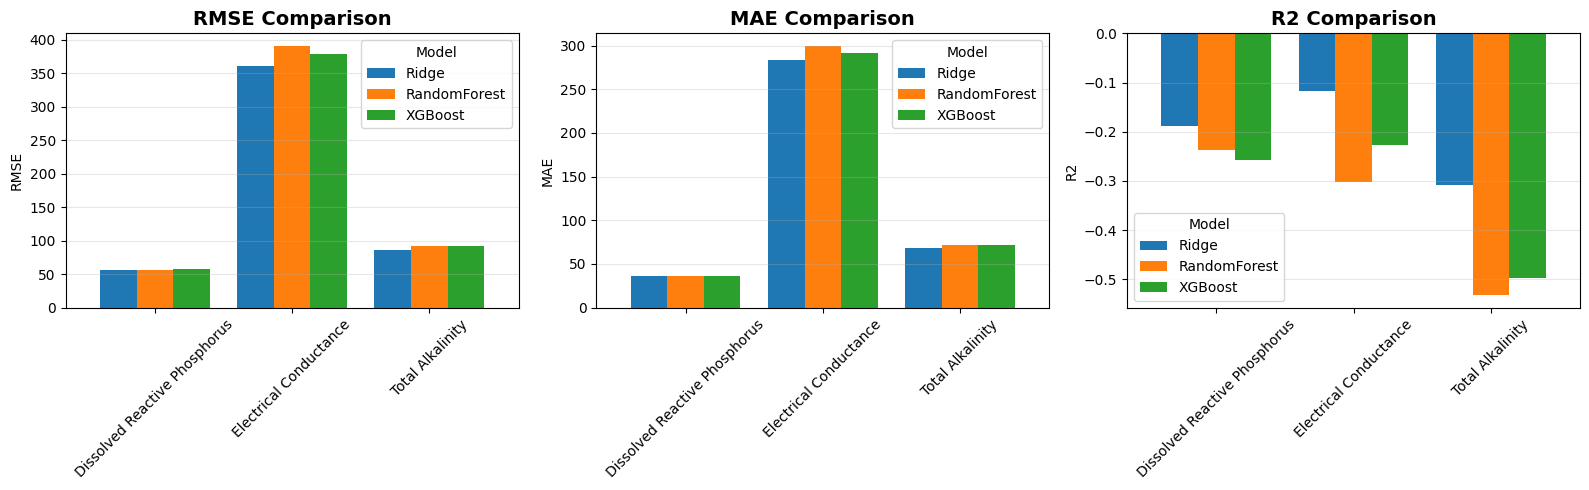


✅ Saved to ../reports/model_comparison.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["rmse", "mae", "r2"]):
    pivot = results_df.pivot(index="target", columns="model", values=metric)
    pivot = pivot[["Ridge", "RandomForest", "XGBoost"]]
    pivot.plot(kind="bar", ax=ax, rot=45, width=0.8)
    ax.set_title(f"{metric.upper()} Comparison", fontsize=14, fontweight='bold')
    ax.set_ylabel(metric.upper())
    ax.set_xlabel("")
    ax.legend(title="Model", loc='best')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Saved to ../reports/model_comparison.png")